In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))


path = '/Volumes/Elements/PTM_project/PARK7/METAD_chainA/DATA_PLUMED/'

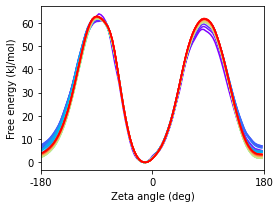

In [4]:
# time course convergence
T=298
sim=1

times = np.arange(220,1020,20)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

data = np.loadtxt(path+'COLVAR.{}'.format(sim))
CV = data[:,1]
rbias = data[:,3]

plt.figure(figsize = (4,3))


for t,c in zip(times,colors):
    
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    plt.plot(x[:-1],fel,color = c)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')
#plt.ylim(0,20)


plt.tight_layout()
plt.savefig('rbias_zeta_FEL_timecourse_sim{}.png'.format(sim))

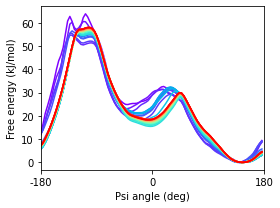

In [5]:
# time course convergence
T=298
sim=3

times = np.arange(220,1020,20)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

data = np.loadtxt(path+'COLVAR.{}'.format(sim))
CV = data[:,2]
rbias = data[:,3]

plt.figure(figsize = (4,3))


for t,c in zip(times,colors):
    
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    plt.plot(x[:-1],fel,color = c)
    
# formatting

plt.xlabel('Psi angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')
#plt.ylim(0,20)


plt.tight_layout()
plt.savefig('rbias_psi_FEL_timecourse_sim{}.png'.format(sim))

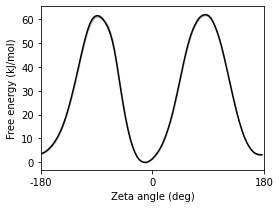

In [2]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Zeta angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_zeta.png')

In [6]:
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis.csv')
df

,Avg %,Err %
0,75.3,0.8


In [8]:
print(mu)
print(err)
print(cis_data)

[75.3]
[0.8]
[0.7714614132412382, 0.7523863858731512, 0.7358241405263368]


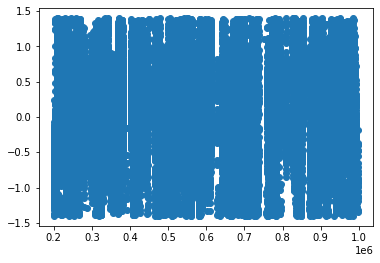

In [8]:
plt.scatter(data[:,0][init_frame:frame][cisframes],CV[init_frame:frame][cisframes])

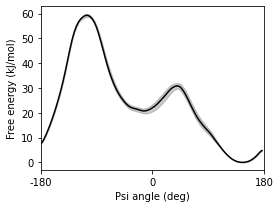

In [9]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,2]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,3))


plt.plot(x[:-1],mu,color = 'black')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Psi angle (deg)')
plt.xlim(-np.pi,np.pi)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=[-180,0,180])
plt.ylabel('Free energy (kJ/mol)')


plt.tight_layout()
plt.savefig('1D_avgFEL_psi.png')

In [10]:
# 2D FELs

<Figure size 288x216 with 0 Axes>

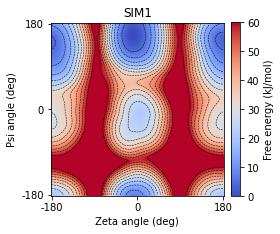

In [11]:
# convergence with rbias reweighting BF15

sim = 1
T = 298

t= 1000
t_discard = 200


data = np.loadtxt(path+'COLVAR.{}'.format(sim))
zeta = data[:,1]
psi = data[:,2]
rbias = data[:,3]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(-np.pi,np.pi,2*np.pi/100)

frame = int(t*1000/5)
init_frame = int(t_discard*1000/5)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=psi[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 60
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = ['-180','0','180']
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,49,98],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))

plt.title('SIM{}'.format(sim))
plt.xlabel('Zeta angle (deg)')
plt.ylabel('Psi angle (deg)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_psi_FEL_sim{}.png'.format(sim))

<Figure size 288x216 with 0 Axes>

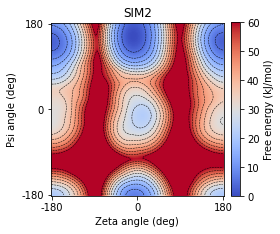

In [12]:
# convergence with rbias reweighting BF15

sim = 2
T = 298

t= 1000
t_discard = 200


data = np.loadtxt(path+'COLVAR.{}'.format(sim))
zeta = data[:,1]
psi = data[:,2]
rbias = data[:,3]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(-np.pi,np.pi,2*np.pi/100)

frame = int(t*1000/5)
init_frame = int(t_discard*1000/5)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=psi[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 60
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = ['-180','0','180']
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,49,98],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))

plt.title('SIM{}'.format(sim))
plt.xlabel('Zeta angle (deg)')
plt.ylabel('Psi angle (deg)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_psi_FEL_sim{}.png'.format(sim))

<Figure size 288x216 with 0 Axes>

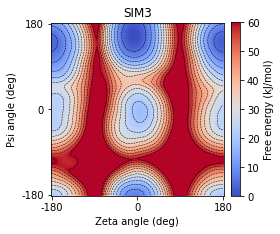

In [13]:
# convergence with rbias reweighting BF15

sim = 3
T = 298

t= 1000
t_discard = 200


data = np.loadtxt(path+'COLVAR.{}'.format(sim))
zeta = data[:,1]
psi = data[:,2]
rbias = data[:,3]

xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
yedges = np.arange(-np.pi,np.pi,2*np.pi/100)

frame = int(t*1000/5)
init_frame = int(t_discard*1000/5)
    
# FEL rbias reweighting
kbt = 0.008314*T

plt.figure(figsize = (4,3))


weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
weights = weights/np.sum(weights)

x=zeta[init_frame:frame]
y=psi[init_frame:frame]

H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
H = gaussian_filter(H, sigma=2)
h = H/np.sum(H) # convert counts to probility
h = -kbt*np.log(h) # calculate free energy from probability
h = h-np.min(h) # set minimum to 0 kbT
h = h.T


max_energy = 60
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='coolwarm')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-180','0','180']
ylabels = ['-180','0','180']
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,49,98],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))

plt.title('SIM{}'.format(sim))
plt.xlabel('Zeta angle (deg)')
plt.ylabel('Psi angle (deg)')

plt.tight_layout()
plt.savefig('2D_zeta_vs_psi_FEL_sim{}.png'.format(sim))

In [7]:
# calculate cis/trans populations in Y67 exposed vs buried

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200



buried_cis = []
exposed_cis = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasaTYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    buried_frames = np.where(SASA[init_frame:frame]<0.35)[0]
    exposed_frames = np.where(SASA[init_frame:frame]>0.35)[0]
    
    buried_cis.append(np.average((np.abs(CV[init_frame:frame][buried_frames])<1.4)*1, weights=weights[buried_frames]))
    exposed_cis.append(np.average((np.abs(CV[init_frame:frame][exposed_frames])<1.4)*1, weights=weights[exposed_frames]))
    
# average and error

mu_buried = np.round(np.mean(buried_cis),2)
err_buried = np.round(np.std(buried_cis)/np.sqrt(nsims),2)

mu_exposed = np.round(np.mean(exposed_cis),2)
err_exposed = np.round(np.std(exposed_cis)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Y67 state'] = ['buried']
df['% P66 cis'] = [mu_buried]
df['Error']  = [err_buried]
df.to_csv('avg_cis_TYR67_state.csv')
df

,Y67 state,% P66 cis,Error
0,buried,0.75,0.01


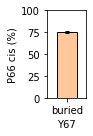

In [12]:
# only plot buried as the simulations do not truly sample exposed Y67 extensively
# Y67 buried population consistent with overall population calculated above 
df = pd.read_csv('avg_cis_TYR67_state.csv')
df['% P66 cis']=df['% P66 cis']*100
df['Error']=df['Error']*100
df.plot(x='Y67 state',y='% P66 cis',yerr= np.array(df['Error']),
       kind='bar',figsize = (1.4,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,100)
plt.xlabel('Y67')

plt.ylabel('P66 cis (%)')

plt.tight_layout()
plt.savefig('P66_cis_population_Y67_states_barplot.pdf')